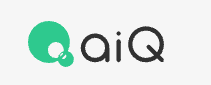

[disclaimer](../../disclaimer.txt/)

# aiQ DataHub: FACTSET TruValue Data Evaluation Notebook
- TruValueは、150,000以上の審査済みの情報源から収集した様々な視点の非構造化データを評価することで生成されたSDG（持続可能な開発目標）センチメント指数です。
- TruValueのアルゴリズムは、SDGに関連する情報を特定し、言語の感情を定量化しセンチメントスコアとして提供します。
- スコアは日々のパフォーマンスの変化を捉え、スポットライトイベントは同じエンティティおよびトピックに関する記事をアルゴリズム的に検出することで、重要なESG（環境・社会・ガバナンス）イベントを捉えます。
- 本評価サンプルは、TruValueによって公開されたセンチメントスコアのみを利用しています。

-------------------------
- TruValue is a collection of SDG sentiment index generated through evaluation of unstructured data from over 150,000 vetted sources with a variety of 
perspective.
- Truvalue algorithms identify SDG relevant information, quantify sentiment in the language and calculates a series of scores and Spotlight Events that align to 16 of the 17 SDG categories.
- The scores capture daily changes in performance, while Spotlight Events capture 
significant ESG events by algorithmically detecting articles pertaining to the same entity and topic
- This evaluation sample only utilizes the sentiment scores published by TruValue.. 

In [2]:
# 自作モジュールを自動更新を行うためのコマンド
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import sys
import numpy as np
import pandas as pd
import plotly.io
from aiq_strategy_robot.data.data_accessor import DAL

for_html = False
if for_html:
    plotly.offline.init_notebook_mode()
else:
    plotly.io.renderers.default = 'iframe'

if '../..' not in sys.path:
    sys.path.append('../..')
from utils.shortcut import truvalue_dataset as sc

In [4]:
verbose = False

- standard data handler のインスタンスを作成する
- data handler はデータ取得やデータ加工のライブラリを保持するオブジェクト

In [5]:
sdh = DAL()

## データロード & AltDataEvaluatorの作成

In [6]:
# Price Data (origin: FactSet HTTP API)
data_id_price = sc.register_market_prices(sdh)
display(sdh.get_raw_data(data_id_price).tail())

# ☆TruValue data (origin: FactSet Snowflake)
data_id_tv = sc.register_tv(sdh)
display(sdh.get_raw_data(data_id_tv).tail())

# Set Alias (Optional)
sdh.set_alias({
    data_id_price: 'mkt',
    data_id_tv: 'truvalue',
})

sdh.extract_definition

fsymId  TICKER_REGION    volume   open   high    low  \
TICKER  DATETIME                                                             
9997-JP 2023-10-27  BT5ZHY-R           9997  290300.0  622.0  628.0  622.0   
        2023-10-30  BT5ZHY-R           9997  409300.0  622.0  625.0  607.0   
        2023-10-31  BT5ZHY-R           9997  528300.0  610.0  613.0  604.0   
        2023-11-01  BT5ZHY-R           9997  421200.0  627.0  633.0  619.0   
        2023-11-02  BT5ZHY-R           9997  323800.0  631.0  631.0  621.0   

                    close currency  
TICKER  DATETIME                    
9997-JP 2023-10-27  626.0      JPY  
        2023-10-30  612.0      JPY  
        2023-10-31  612.0      JPY  
        2023-11-01  628.0      JPY  
        2023-11-02  628.0      JPY

MATERIALITY_ADJ_INSIGHT  MATERIALITY_IND_PCTL  \
TICKER  DATETIME                                                    
9997-JP 2023-11-16                    64.42                 40.63   
        2023-11-17                    64.41                 40.35   
        2023-11-18                    64.40                 40.28   
        2023-11-19                    64.35                 40.37   
        2023-11-20                    64.40                 40.23   

                    ALL_CATEGORIES_ADJ_INSIGHT  ALL_CATEGORIES_INSIGHT  \
TICKER  DATETIME                                                         
9997-JP 2023-11-16                       76.55               76.545724   
        2023-11-17                       76.56               76.564881   
        2023-11-18                       76.58               76.583965   
        2023-11-19                       76.60               76.602976   
        2023-11-20                       76.62               76.621916   

                    ALL_CATEGORIES_MOMENTUM  ALL_CATEGORIES_PULSE  
TICKER  DATETIME                                                   
9997-JP 2023-11-16                81.457731               81.5853  
        2023-11-17                81.409830               81.5853  
        2023-11-18                81.362007               81.5853  
        2023-11-19                81.314263               81.5853  
        2023-11-20                81.266596               81.5853

,category,data_source,source,table,alias,tickers,index,start_datetime,end_datetime
data_id,,,,,,,,,
1,RawData,FACTSET,gpd_prices,Unknown,mkt,"[1301-JP, 1332-JP, 1333-JP, 1379-JP, 1380-JP, ...","[TICKER, DATETIME]",2016-01-04 00:00:00,2023-11-02 00:00:00
2,RawData,FACTSET,TrueValue,Unknown,truvalue,"[1301-JP, 1332-JP, 1333-JP, 1379-JP, 1380-JP, ...","[TICKER, DATETIME]",2016-01-01 00:00:00,2023-11-20 00:00:00


### AltDataEvaluatorを作成

In [7]:
from aiq_strategy_robot.evaluator import AltDataEvaluator

# Initialize AltDataEvaluator
ade = AltDataEvaluator(sdh)

## 相関計算

### 株価変化率との相関

> ここでは週次データに変換して分析します.

In [23]:
mkt_open_id = sdh.transform.raw(data_id=data_id_price, fields='open').variable_ids[-1]
mkt_close_id = sdh.transform.raw(data_id=data_id_price, fields='close').variable_ids[-1]

tv_last_ids = sdh.transform.resample_by(label=mkt_close_id, func='last', data_id=data_id_tv).variable_ids

In [22]:
ori_cols = sdh.get_raw_data(data_id_tv).columns.to_list()
ori_cols

['MATERIALITY_ADJ_INSIGHT',
 'MATERIALITY_IND_PCTL',
 'ALL_CATEGORIES_ADJ_INSIGHT',
 'ALL_CATEGORIES_INSIGHT',
 'ALL_CATEGORIES_MOMENTUM',
 'ALL_CATEGORIES_PULSE']

#### TruValueの集約方法毎に相関を確認

##### 1. resample -last

価格データとTrueValueをプロット

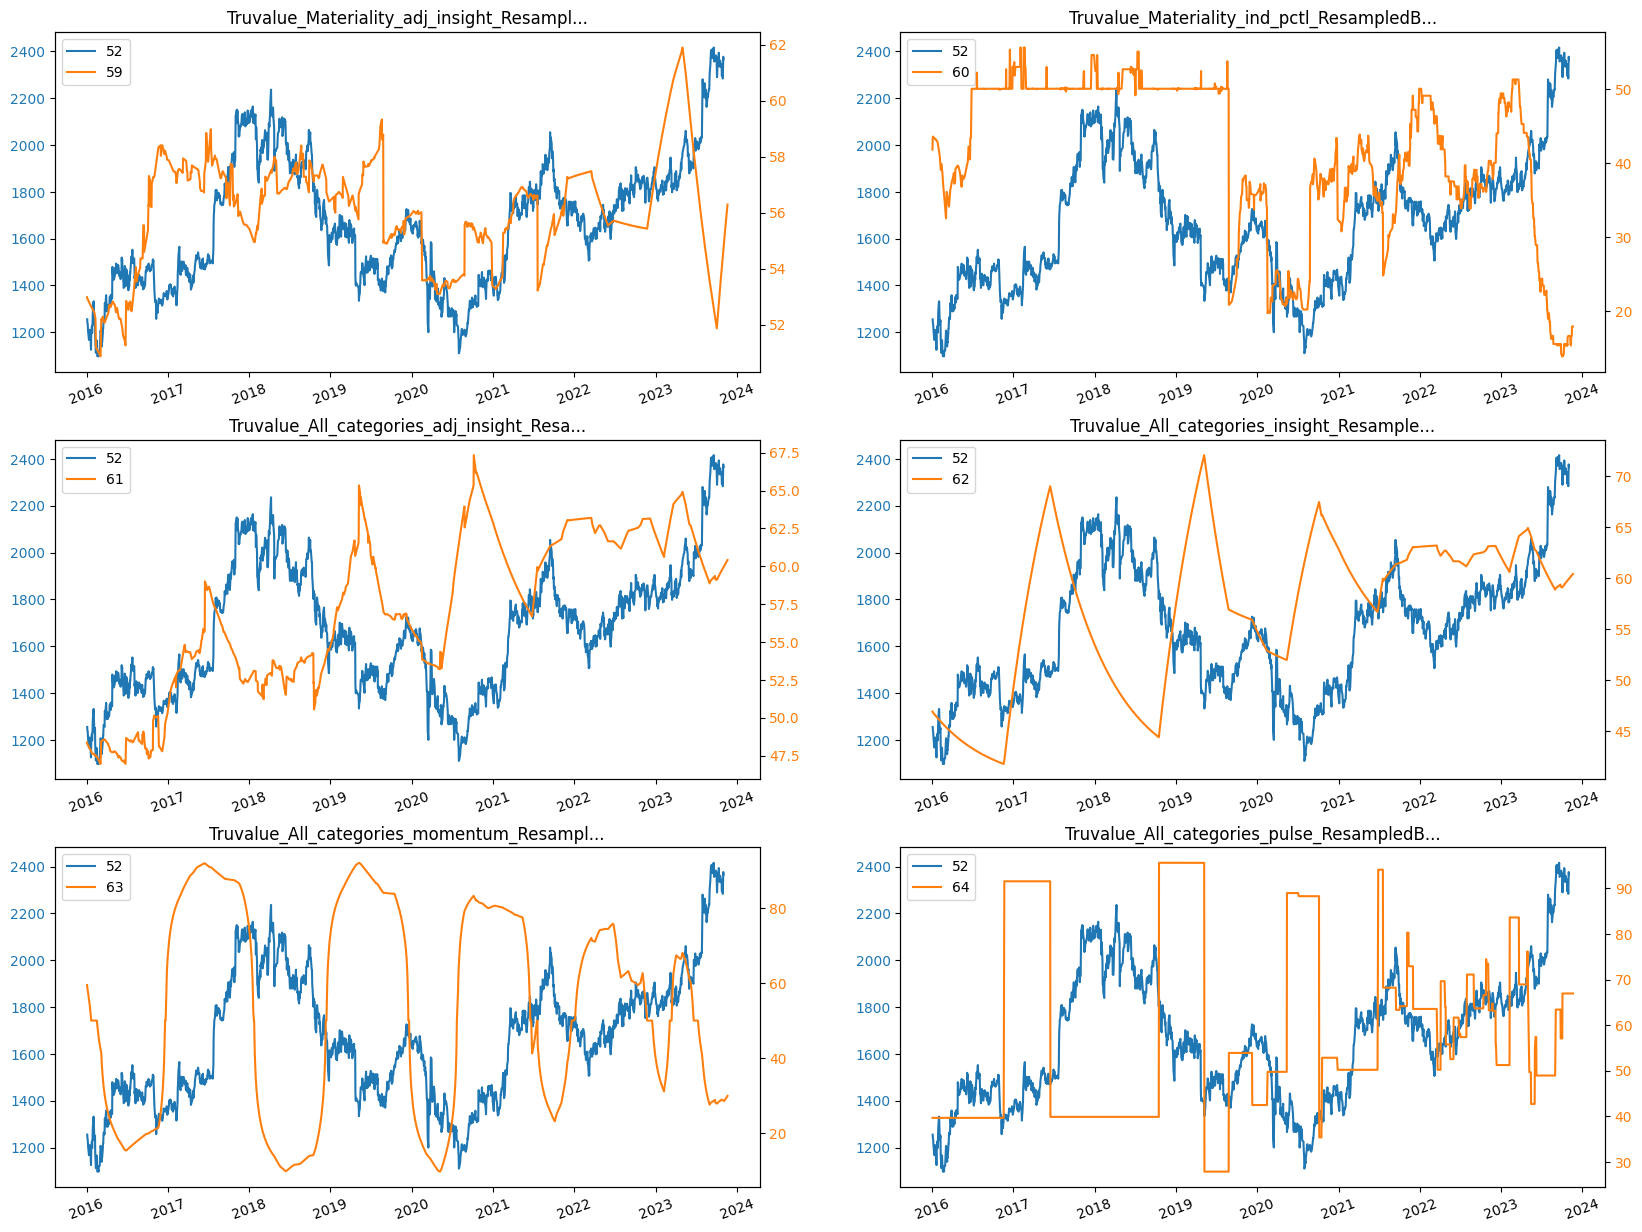

In [26]:
sample_target = "7984-JP"

sdh.show_line_one_target(
    target=sample_target,
    y=mkt_close_id,
    X= tv_last_ids,
    col_num=2,
    vname_len_limit=40,
)

> データの時系列をshiftすることで売上高とのプロットがどのように変化するかを見ます.

In [12]:
tv_shift4_last_W_ids = sdh.transform.shift(data_id=data_id_tv, periods=4).variable_ids
tv_shift8_last_W_ids = sdh.transform.shift(data_id=data_id_tv, periods=8).variable_ids
tv_shift12_last_W_ids = sdh.transform.shift(data_id=data_id_tv, periods=12).variable_ids
tv_shift16_last_W_ids = sdh.transform.shift(data_id=data_id_tv, periods=16).variable_ids
tv_shift20_last_W_ids = sdh.transform.shift(data_id=data_id_tv, periods=20).variable_ids

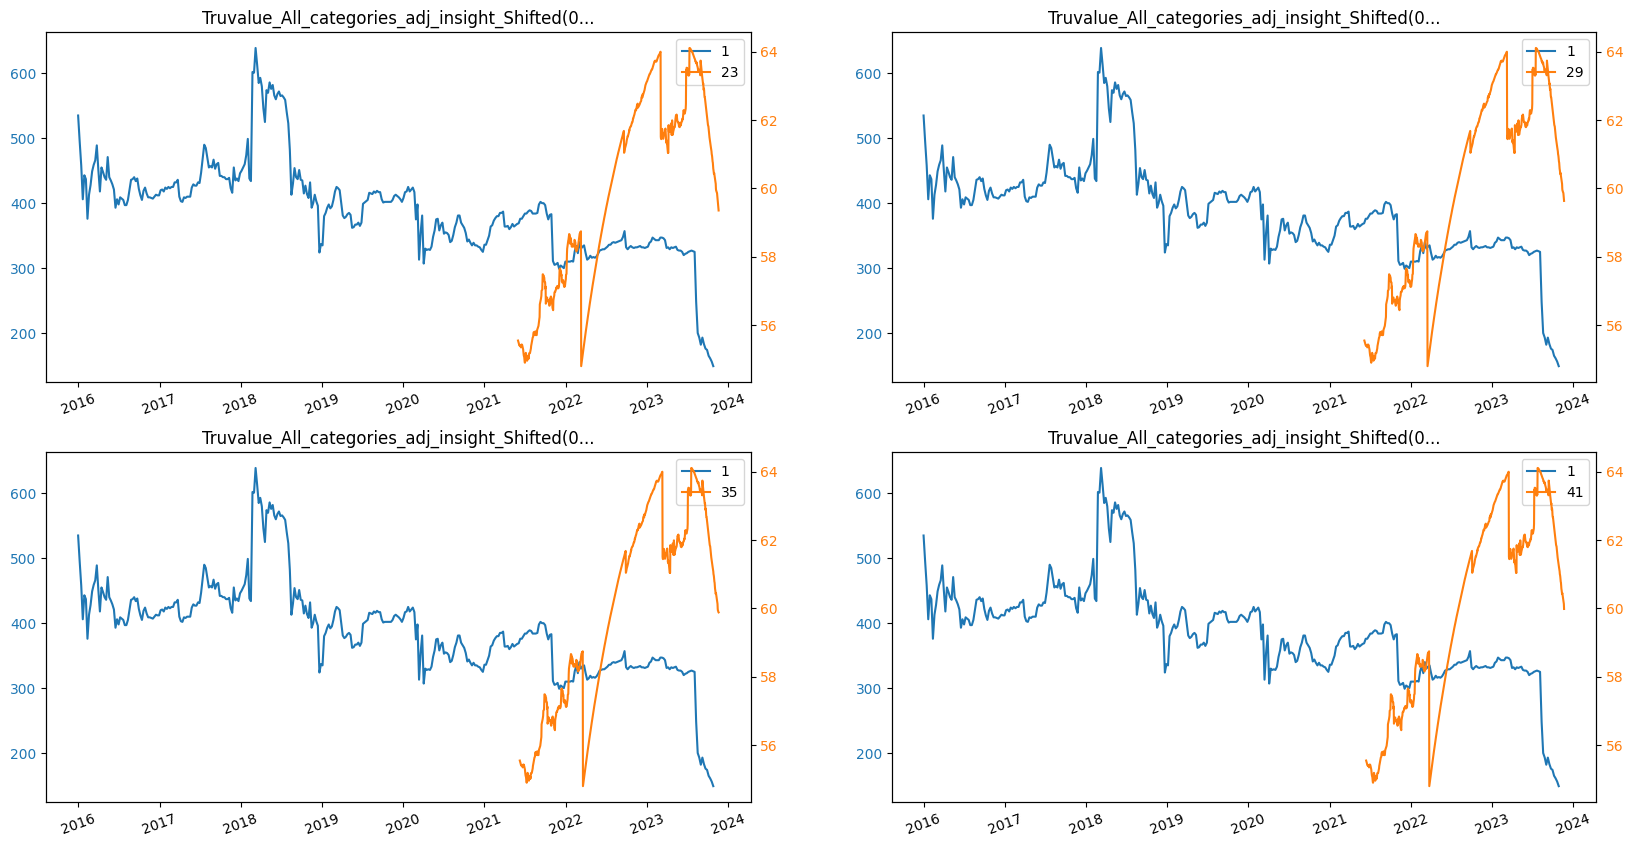

In [13]:
sdh.show_line_one_target(
    target=sample_target,
    y=mkt_W_open_id,
    X= [tv_shift4_last_W_ids[2], tv_shift8_last_W_ids[2], 
        tv_shift12_last_W_ids[2], tv_shift16_last_W_ids[2]],
    col_num=2,
    vname_len_limit=45,
)

> 特徴量を対数変換して相関計算を行う<br>
> TruValueはそのままで使用(shiftのみ）

In [29]:
open_return = sdh.transform.dropna(fields=mkt_open_id).log_diff(periods=1).multiply_by_scalar(value=100).variable_ids[-1]
close_return = sdh.transform.dropna(fields=mkt_close_id).log_diff(periods=1).multiply_by_scalar(value=100).variable_ids[-1]

In [36]:
shifter = 3
tv_ld1_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=1).variable_ids
tv_ld2_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=2).variable_ids
tv_ld3_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=3).variable_ids
tv_ld4_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=4).variable_ids
tv_ld5_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=5).variable_ids
tv_ld6_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=6).variable_ids
tv_ld7_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=7).variable_ids
tv_ld14_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=14).variable_ids
tv_ld30_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=30).variable_ids
tv_ld252_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=252).variable_ids
tv_ld1_d1_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=1).diff(1).variable_ids
tv_ld2_d1_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=2).diff(1).variable_ids
tv_ld3_d1_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=3).diff(1).variable_ids
tv_ld4_d1_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=4).diff(1).variable_ids
tv_ld5_d1_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=5).diff(1).variable_ids
tv_ld6_d1_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=6).diff(1).variable_ids
tv_ld7_d1_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=7).diff(1).variable_ids
tv_ld14_d1_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=14).diff(1).variable_ids
tv_ld30_d1_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=30).diff(1).variable_ids
tv_ld252_d1_last_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample_by(label=mkt_close_id, func='last').log_diff(periods=252).diff(1).variable_ids

In [194]:
shifter = 2
tv_ld1_last_W_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample(rule=resample_term, func='last', label='left', closed='left').log_diff(periods=1).variable_ids
tv_ld2_last_W_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample(rule=resample_term, func='last', label='left', closed='left').log_diff(periods=2).variable_ids
tv_ld3_last_W_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample(rule=resample_term, func='last', label='left', closed='left').log_diff(periods=3).variable_ids
tv_ld4_last_W_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample(rule=resample_term, func='last', label='left', closed='left').log_diff(periods=4).variable_ids
tv_ld8_last_W_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample(rule=resample_term, func='last', label='left', closed='left').log_diff(periods=8).variable_ids
tv_ld12_last_W_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample(rule=resample_term, func='last', label='left', closed='left').log_diff(periods=12).variable_ids
tv_ld26_last_W_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample(rule=resample_term, func='last', label='left', closed='left').log_diff(periods=26).variable_ids
tv_ld52_last_W_ids = sdh.transform.shift(data_id=data_id_tv, periods=shifter).resample(rule=resample_term, func='last', label='left', closed='left').log_diff(periods=52).variable_ids

In [39]:
rho_pool_last = pd.DataFrame()
rho_pool_last['resample-last, ld=1'] = ade.compu_rho(tv_ld1_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=2'] = ade.compu_rho(tv_ld2_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=3'] = ade.compu_rho(tv_ld3_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=4'] = ade.compu_rho(tv_ld4_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=5'] = ade.compu_rho(tv_ld5_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=6'] = ade.compu_rho(tv_ld6_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=7'] = ade.compu_rho(tv_ld7_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=14'] = ade.compu_rho(tv_ld14_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=30'] = ade.compu_rho(tv_ld30_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=252'] = ade.compu_rho(tv_ld252_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=1, d1'] = ade.compu_rho(tv_ld1_d1_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=2, d1'] = ade.compu_rho(tv_ld2_d1_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=3, d1'] = ade.compu_rho(tv_ld3_d1_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=4, d1'] = ade.compu_rho(tv_ld4_d1_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=5, d1'] = ade.compu_rho(tv_ld5_d1_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=6, d1'] = ade.compu_rho(tv_ld6_d1_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=7, d1'] = ade.compu_rho(tv_ld7_d1_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=14, d1'] = ade.compu_rho(tv_ld14_d1_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=30, d1'] = ade.compu_rho(tv_ld30_d1_last_ids, close_return, rename_features=ori_cols)
rho_pool_last['resample-last, ld=252, d1'] = ade.compu_rho(tv_ld252_d1_last_ids, close_return, rename_features=ori_cols)

display(rho_pool_last.xs('t-val', level=1).loc[ori_cols].sort_values(rho_pool_last.columns[0], ascending=False))

,"resample-last, ld=1","resample-last, ld=2","resample-last, ld=3","resample-last, ld=4","resample-last, ld=5","resample-last, ld=6","resample-last, ld=7","resample-last, ld=14","resample-last, ld=30","resample-last, ld=252","resample-last, ld=1, d1","resample-last, ld=2, d1","resample-last, ld=3, d1","resample-last, ld=4, d1","resample-last, ld=5, d1","resample-last, ld=6, d1","resample-last, ld=7, d1","resample-last, ld=14, d1","resample-last, ld=30, d1","resample-last, ld=252, d1"
ALL_CATEGORIES_ADJ_INSIGHT,2.773919,2.500815,1.285109,0.545928,0.636808,1.503448,1.481044,1.658484,0.982810,1.381267,0.552369,2.123728,2.679937,2.298228,-0.000610,0.046979,1.727651,2.466113,2.691227,3.276008
ALL_CATEGORIES_INSIGHT,1.968106,2.126879,1.824027,1.677246,1.582250,1.778368,1.876143,1.962416,1.808451,2.982777,-0.395533,0.091071,0.590017,0.180619,-1.376120,-0.681550,0.619010,-0.456461,1.278618,0.272139
MATERIALITY_ADJ_INSIGHT,0.378181,0.095866,0.005113,-1.027245,-1.461454,-0.658890,-0.700798,0.743186,0.726259,2.913581,1.856765,0.289432,1.128585,1.505198,-1.130027,0.564310,-1.696865,-1.606425,1.064996,1.582847
ALL_CATEGORIES_MOMENTUM,0.095976,0.262675,0.110482,0.103536,0.213282,0.431358,0.467487,0.522523,0.727413,0.772749,1.177351,-1.094870,0.155339,-0.727804,-1.146840,0.053890,-1.101228,-0.576473,-1.068934,1.399322
ALL_CATEGORIES_PULSE,-0.395826,-1.065565,-0.861867,-0.796916,-0.671753,-0.474193,0.061254,0.172348,0.127150,1.332965,1.162842,0.303775,0.217317,0.029124,-0.069173,-0.343955,0.760866,0.799929,-0.125115,1.429372
MATERIALITY_IND_PCTL,-0.977772,-0.073260,0.323110,0.562588,0.670690,0.809811,1.639193,0.830548,0.283772,2.629444,-0.674550,-0.068391,-1.318740,-0.282936,-0.703435,-1.221561,-1.256019,-2.955081,-1.435000,0.536202


> もっとも相関の良い変数のうち、さらに上記N件のTickerを確認します.

In [42]:
rho_time = ade.compu_rho(tv_ld252_d1_last_ids, close_return, by='ticker', rename_features=ori_cols)
rho_time.T.xs('t-val', level=1).loc[:, ori_cols].sort_values('ALL_CATEGORIES_ADJ_INSIGHT', ascending=False).head()

/home/schiba/miniconda3/envs/sample/lib/python3.9/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

/home/schiba/miniconda3/envs/sample/lib/python3.9/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

/home/schiba/miniconda3/envs/sample/lib/python3.9/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



,MATERIALITY_ADJ_INSIGHT,MATERIALITY_IND_PCTL,ALL_CATEGORIES_ADJ_INSIGHT,ALL_CATEGORIES_INSIGHT,ALL_CATEGORIES_MOMENTUM,ALL_CATEGORIES_PULSE
TICKER,,,,,,
3069-JP,2.977228,3.389728,3.576600,3.209921,2.607366,-0.396299
4578-JP,0.767680,0.007677,3.022182,2.392322,1.040709,1.403439
2875-JP,-0.187537,-0.136350,2.487252,1.968213,1.659587,-0.341407
2914-JP,2.300963,-1.175053,2.351689,2.478132,2.529234,0.960081
4623-JP,-0.558453,-2.007164,2.185398,NaN,NaN,NaN


In [58]:
display(sdh.transform.find_variables(tv_ld252_last_ids))

feature_last = 175 # ALL_CATEGORIES_PULSE

,variable_id,data_id,data_source,source,table,field,ticker,reference_id,variable_type,method,params,process_id
variable_name,,,,,,,,,,,,
"Truvalue_Materiality_adj_insight_Shifted(003)_ResampledBy(label=""Mkt_Close"", func=""last"")_LogDiff(252)",167,2,FACTSET,TrueValue,Unknown,Truvalue_Materiality_adj_insight_Shifted(003)_...,None,83,reference,log_diff,periods=252,42
"Truvalue_Materiality_ind_pctl_Shifted(003)_ResampledBy(label=""Mkt_Close"", func=""last"")_LogDiff(252)",168,2,FACTSET,TrueValue,Unknown,Truvalue_Materiality_ind_pctl_Shifted(003)_Res...,None,84,reference,log_diff,periods=252,42
"Truvalue_All_categories_adj_insight_Shifted(003)_ResampledBy(label=""Mkt_Close"", func=""last"")_LogDiff(252)",169,2,FACTSET,TrueValue,Unknown,Truvalue_All_categories_adj_insight_Shifted(00...,None,85,reference,log_diff,periods=252,42
"Truvalue_All_categories_insight_Shifted(003)_ResampledBy(label=""Mkt_Close"", func=""last"")_LogDiff(252)",170,2,FACTSET,TrueValue,Unknown,Truvalue_All_categories_insight_Shifted(003)_R...,None,86,reference,log_diff,periods=252,42
"Truvalue_All_categories_momentum_Shifted(003)_ResampledBy(label=""Mkt_Close"", func=""last"")_LogDiff(252)",171,2,FACTSET,TrueValue,Unknown,Truvalue_All_categories_momentum_Shifted(003)_...,None,87,reference,log_diff,periods=252,42
"Truvalue_All_categories_pulse_Shifted(003)_ResampledBy(label=""Mkt_Close"", func=""last"")_LogDiff(252)",172,2,FACTSET,TrueValue,Unknown,Truvalue_All_categories_pulse_Shifted(003)_Res...,None,88,reference,log_diff,periods=252,42


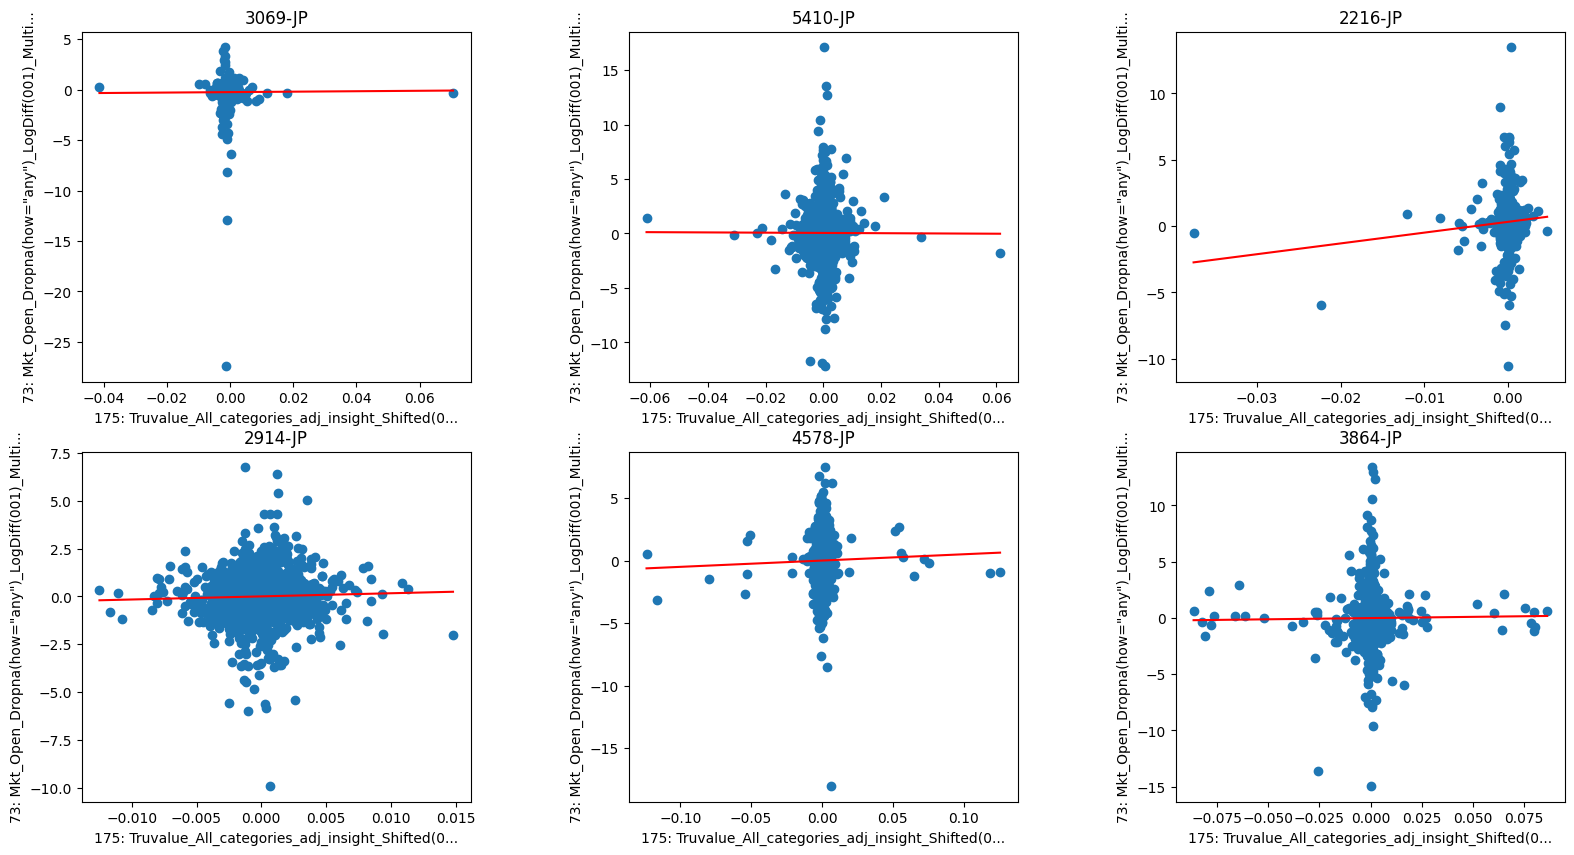

In [46]:
top6tickers = rho_time.T.xs('t-val', level=1).sort_values('ALL_CATEGORIES_INSIGHT', ascending=False).index[:6]

sdh.show_scatter_per_target(
    y=open_return,
    x=feature_last,
    targets=top6tickers,
    col_num=3,
    vname_len_limit=45
)

## バックテスト
> TruValueの集約方法ごとに、株価変化率ともっとも相関の良い特徴量をシグナルにして、ポートフォリオ分析を実施します.

In [73]:
# define the parameters for factor choice.
nq = 3
exe_cost = 0.0005

### Resample - last

In [75]:
dfqret, stats, dfsigqt = ade.q_backtest(
    173,
    close_return,
    nq=nq,
    exe_cost=exe_cost,
    plot=True,
    stats=True
)

,cum.Ret,ann.Ret,ann.Std,R/R,Win_R,ann.TurnOver,Max_DD,Calmar Ratio
#1,-2.920728,-0.426939,15.044223,-0.028379,0.509025,101.152384,-54.112425,-0.007890
#2,27.778280,4.060502,15.178264,0.267521,0.533093,126.892352,-42.048959,0.096566
#3,30.259062,4.423131,14.998734,0.294900,0.521661,102.674294,-41.420146,0.106787
#3-#1,33.179790,4.850069,5.124783,0.946395,0.522262,203.826679,-6.177124,0.785166
#3-#1(cost),32.490061,4.749248,5.124812,0.926717,0.521661,203.826679,-6.218206,0.763765
